# Model Demo

This demo shows how the trained YOLO11 model loads, processes meal images, and returns food component detections with labels and confidence scores.

## 1. Install Ultralytics

The Ultralytics package is installed to provide access to the YOLO11 model and prediction tools.

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


## 2. Load the Trained Model

The trained `best.pt` file is loaded as a YOLO11 model for food component detection.

In [5]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

## 3. Verify the Model

The model is checked to confirm that it loaded correctly and contains the 10 food component classes.

In [6]:
print("Model loaded successfully!")
print(model.names)

Model loaded successfully!
{0: 'bread', 1: 'rice', 2: 'potato', 3: 'egg', 4: 'cheese', 5: 'tomato', 6: 'carrot', 7: 'cucumber', 8: 'salad', 9: 'fruit'}


## 4. Run Inference

The model analyzes the meal image using a confidence threshold of 0.25 and saves the annotated prediction.

In [7]:
results = model.predict(
    source="/content/15.jpeg",
    conf=0.25,
    save=True
)


image 1/1 /content/15.jpeg: 640x640 1 potato, 1 carrot, 443.0ms
Speed: 17.2ms preprocess, 443.0ms inference, 35.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


## 5. Run Inference on a Successful Example

 The model analyzes a meal image that produced a strong result, detecting potato and carrot.

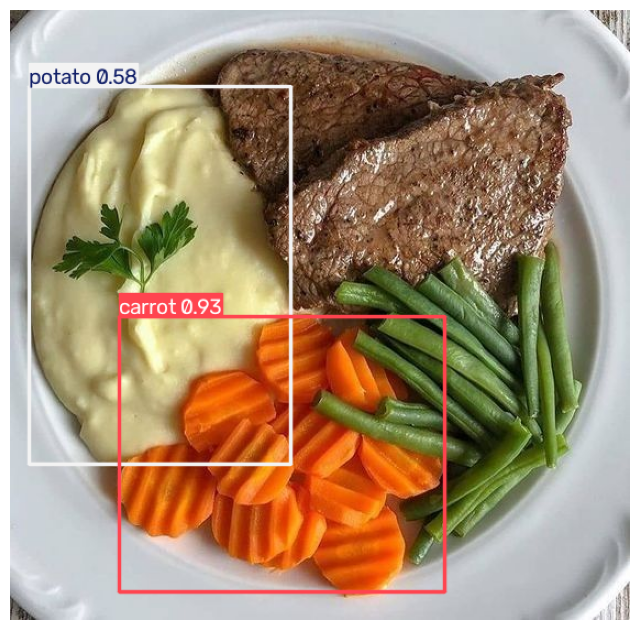

In [10]:
from matplotlib import pyplot as plt

annotated = results[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

## 6. Model Limitation

This example shows a weaker result on a new meal image. The model misclassifies the tuna as `rice` and the chopped egg as `cucumber`, showing that visually similar textures can still confuse the detector.

In [11]:
results_2 = model.predict(
    source="/content/12.jpeg",
    conf=0.25,
    save=True
)


image 1/1 /content/12.jpeg: 640x448 1 rice, 2 cucumbers, 164.2ms
Speed: 3.3ms preprocess, 164.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict


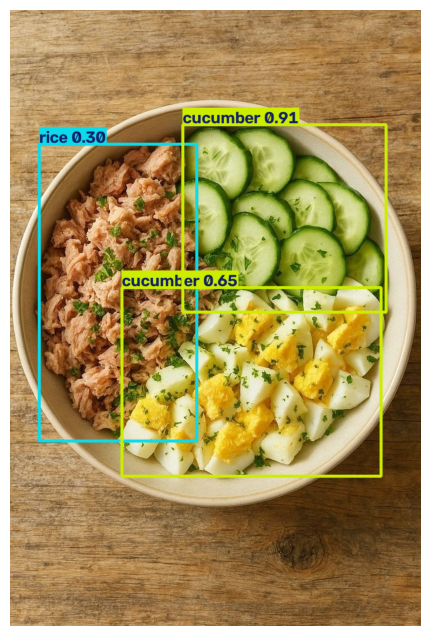

In [12]:
from matplotlib import pyplot as plt

annotated_2 = results_2[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(annotated_2[..., ::-1])
plt.axis("off")
plt.show()